
STARTING LOAD CASE: uniaxial_tension_x
   Target Load: 0.4000 | Initial da: 1.00e-02

Step   1 | Progress:   2.50% | Loading: 0.010000
   Attempting da: 1.00e-02
   SUCCESS: Converged in 2 iterations.
   Stats: Wbar=9.0753e-05 | Jbar=1.0100 | P_max=1.8129e-02
   Increasing step size: 1.00e-02 -> 1.30e-02

Step   2 | Progress:   5.75% | Loading: 0.023000
   Attempting da: 1.30e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=4.7858e-04 | Jbar=1.0230 | P_max=4.1501e-02
   Increasing step size: 1.30e-02 -> 1.69e-02

Step   3 | Progress:   9.98% | Loading: 0.039900
   Attempting da: 1.69e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=1.4346e-03 | Jbar=1.0399 | P_max=7.1575e-02
   Computing Tangent stiffness...
   Done.
   Increasing step size: 1.69e-02 -> 2.20e-02

Step   4 | Progress:  15.47% | Loading: 0.061870
   Attempting da: 2.20e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=3.4321e-03 | Jbar=1.0619 | P_max=1.1018e-01
   Increasing step size: 2.20e-02

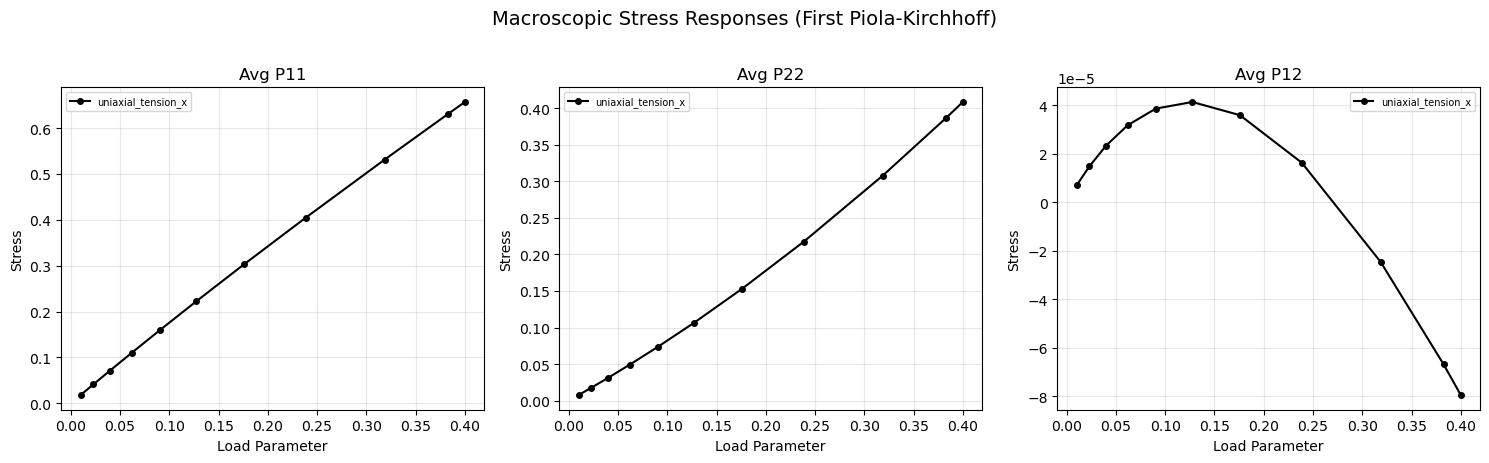

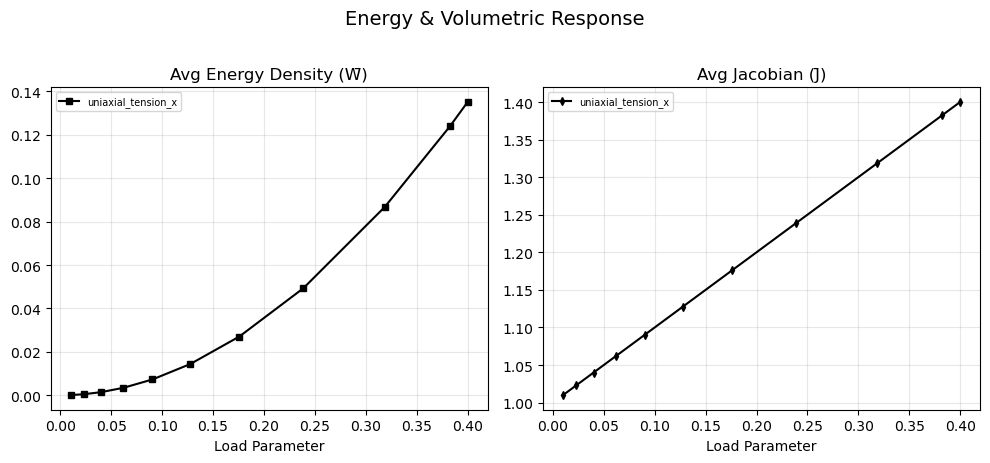

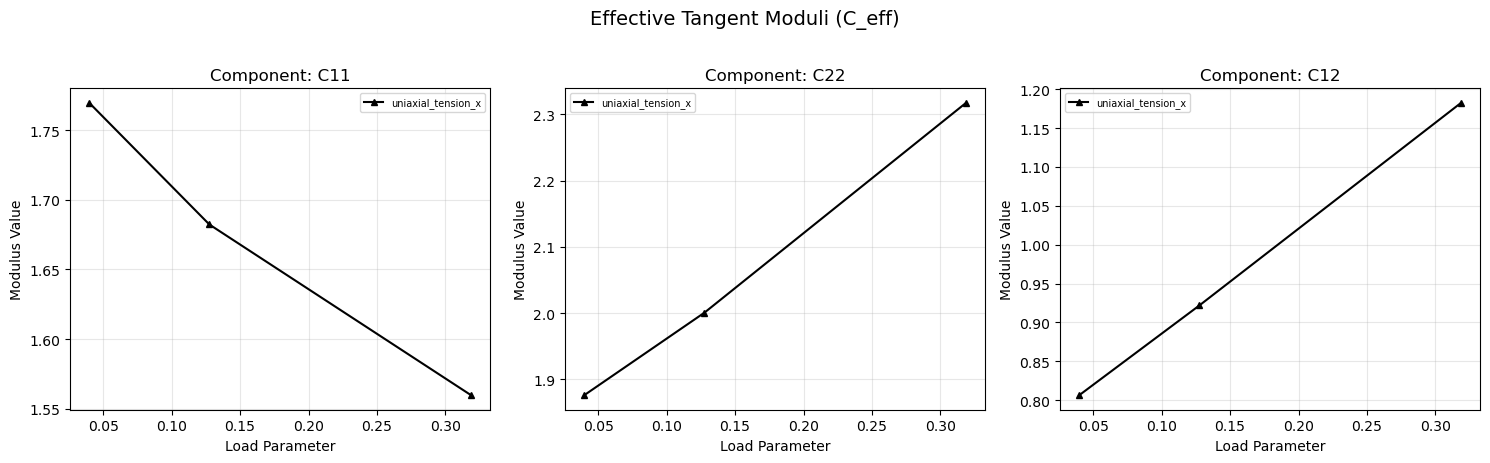

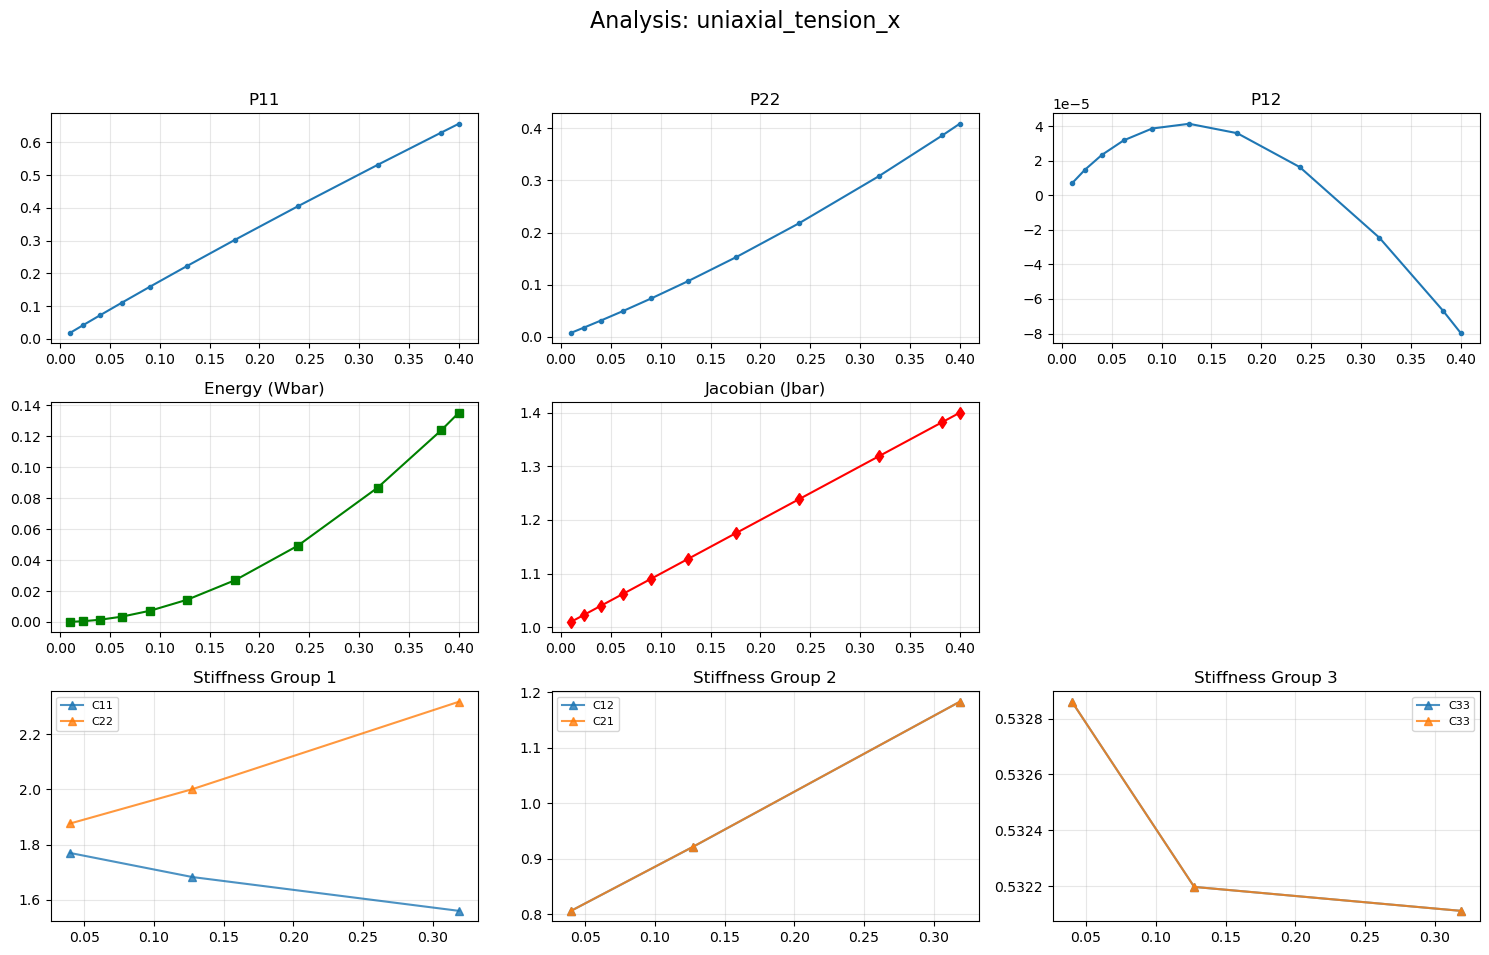

{'uniaxial_tension_x': {'load': array([0.01      , 0.023     , 0.0399    , 0.06187   , 0.090431  ,
       0.1275603 , 0.17582839, 0.23857691, 0.31857691, 0.38257691,
       0.4       ]), 'P11': array([0.01812874, 0.04150148, 0.07157486, 0.11017701, 0.15959228,
       0.22266279, 0.30291615, 0.40474199, 0.53117692, 0.63008053,
       0.65670747]), 'P22': array([0.00761583, 0.01770647, 0.03114907, 0.0491774 , 0.07355792,
       0.1068651 , 0.15292072, 0.21751135, 0.30768837, 0.38621034,
       0.40857486]), 'Wbar': array([9.07531165e-05, 4.78580457e-04, 1.43455810e-03, 3.43208813e-03,
       7.28650300e-03, 1.43867943e-02, 2.70785026e-02, 4.92943510e-02,
       8.67539449e-02, 1.23923766e-01, 1.35133853e-01]), 'Jbar': array([1.01      , 1.023     , 1.0399    , 1.06186999, 1.09043099,
       1.12756028, 1.17582835, 1.23857684, 1.31857679, 1.38257673,
       1.39999981]), 'P12': array([ 6.86831872e-06,  1.47390333e-05,  2.32794341e-05,  3.17189994e-05,
        3.85809299e-05,  4.13192459e-

In [1]:
import petsc4py.PETSc as PETSc
import numpy as np

from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    NeoHookeanIsotropic,
    ProblemSettings,
)
from homicsx.geometry import patriculate_geometry_generator
from homicsx.mesh import generate_mesh
from homicsx.homogenization import solve_nonlinear_homogenization, AdaptiveSettings, plot_homogenization_summary, plot_each_load_case
from homicsx.visualization import visualize_geometry
# ------------------------------------------------------------------------------
# Mesh Generation
# ------------------------------------------------------------------------------
dim = 2

geometry_input = GeometryInput(
    dim=dim,
    dispersion="mono",
    volume_fraction=0.2,
    num_particles=50,
    clearance=0.03,
    domain_size=(1, 1),
    shape="circle",
    seed=42,
)

geometry = patriculate_geometry_generator(geometry_input)

# visualize_geometry(geometry)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.01,
    max_size=0.02,
    physical_tags=physical_tags,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

matrix_tag = physical_tags.cell_tag_for_phase(0)
inclusion_tag = physical_tags.cell_tag_for_phase(1)

# ------------------------------------------------------------------------------
# Material assignment
# ------------------------------------------------------------------------------
E_mat = 1.0
nu_mat = 0.3
mat_matrix = NeoHookeanIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 50.0
nu_inc = 0.3
mat_particle = NeoHookeanIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

# ------------------------------------------------------------------------------
# FEM problem settings
# ------------------------------------------------------------------------------
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='finite_strain',
    two_dimensional_formulation='plane_strain',
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-6,
        "snes_atol": 1e-6,
        "snes_max_it": 10,
    }
)

def uni_tension_func(a):
    F = np.eye(2, dtype=PETSc.ScalarType)
    F[0, 0] = 1.0 + a
    return F

summary = solve_nonlinear_homogenization(
    mesh_obj=domain,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=geometry_input.domain_size,
    matrix_phase_id=0,
    tangent_every = 3,
    tangent_delta = 1e-5,
    output_prefix = "rve",
    max_strain = 0.4,
    custom_loads={
        'uniaxial_tension_x': uni_tension_func,
    },
    from_built_in_loads=[],#['uniaxial_x'],
    adaptive_settings=AdaptiveSettings(
        min_step= 1e-6,
        target_iters_min=4,
        target_iters_max=8,
        cutback_factor=0.8,
        growth_factor=1.3,
    ),
    xdmf_opt=True,
    csv_opt=False,
)

plot_homogenization_summary(summary, dim=dim, save=False)
plot_each_load_case(summary, dim=dim, save=False)

print(summary)


STARTING LOAD CASE: uniaxial_x
   Target Load: 0.2000 | Initial da: 5.00e-03

Step   1 | Progress:   2.50% | Loading: 0.005000
   Attempting da: 5.00e-03
   SUCCESS: Converged in 2 iterations.
   Stats: Wbar=2.4337e-05 | Jbar=0.9951 | P_max=9.7411e-03
   Increasing step size: 5.00e-03 -> 7.50e-03

Step   2 | Progress:   6.25% | Loading: 0.012500
   Attempting da: 7.50e-03
   SUCCESS: Converged in 2 iterations.
   Stats: Wbar=1.5241e-04 | Jbar=0.9877 | P_max=2.4424e-02
   Increasing step size: 7.50e-03 -> 1.13e-02

Step   3 | Progress:  11.88% | Loading: 0.023750
   Attempting da: 1.13e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=5.5184e-04 | Jbar=0.9767 | P_max=4.6619e-02
   Computing Tangent stiffness...
        Perturbed solve completed at col 0: reason=2, iters=3
        Perturbed solve completed at col 1: reason=2, iters=3
        Perturbed solve completed at col 2: reason=2, iters=3
        Perturbed solve completed at col 3: reason=2, iters=3
        Perturbed solve

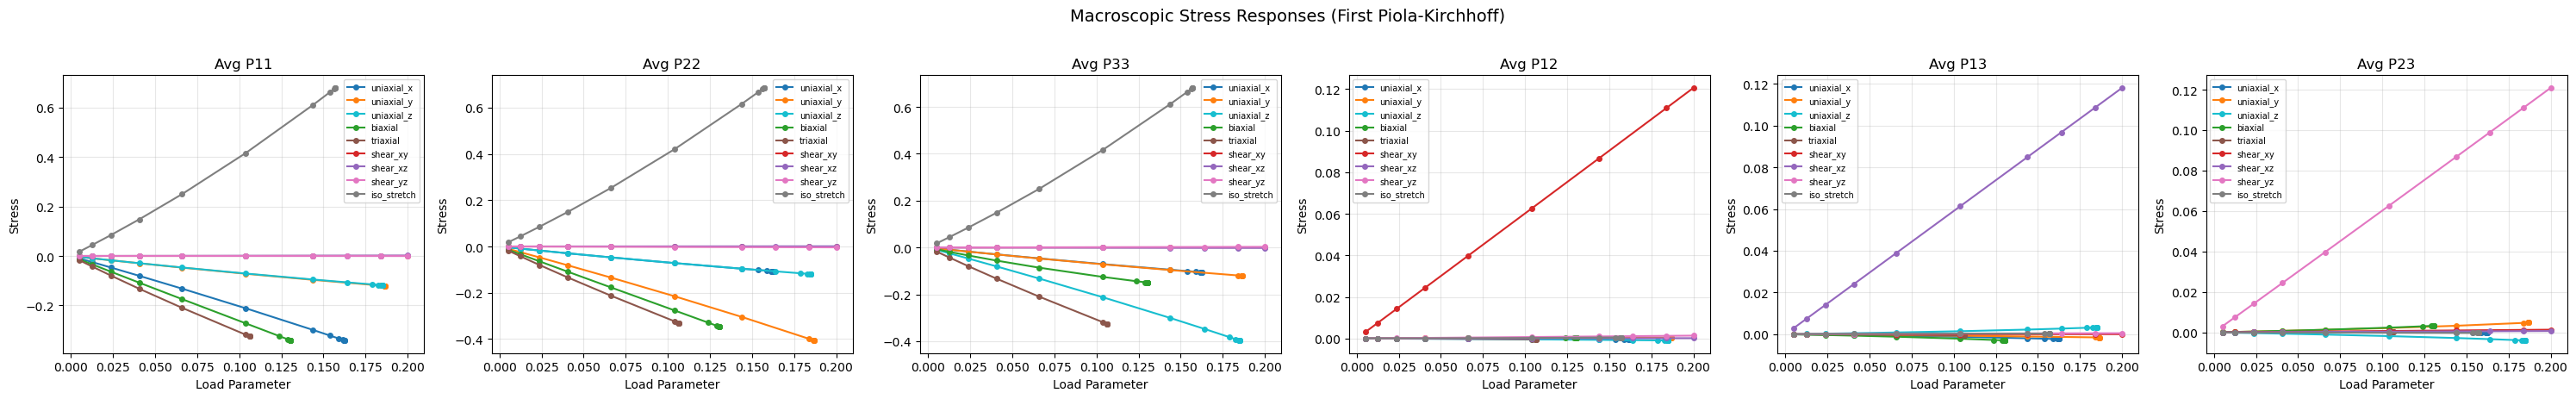

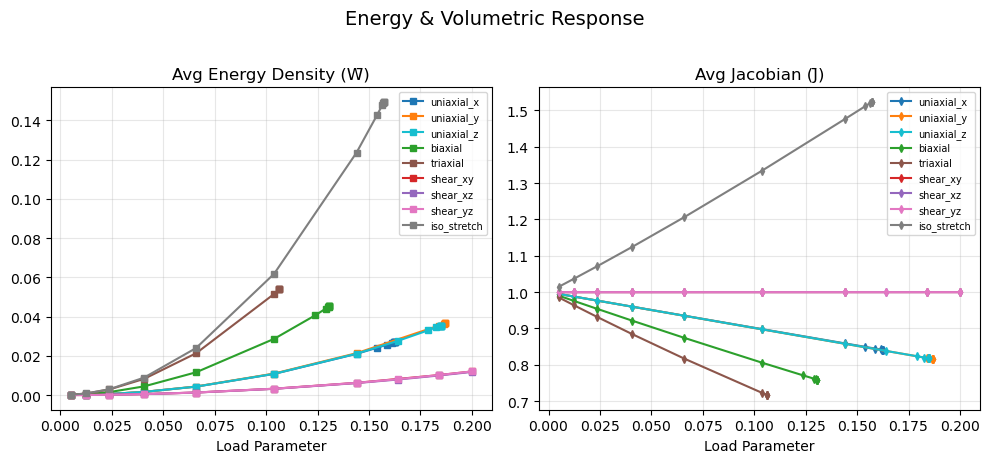

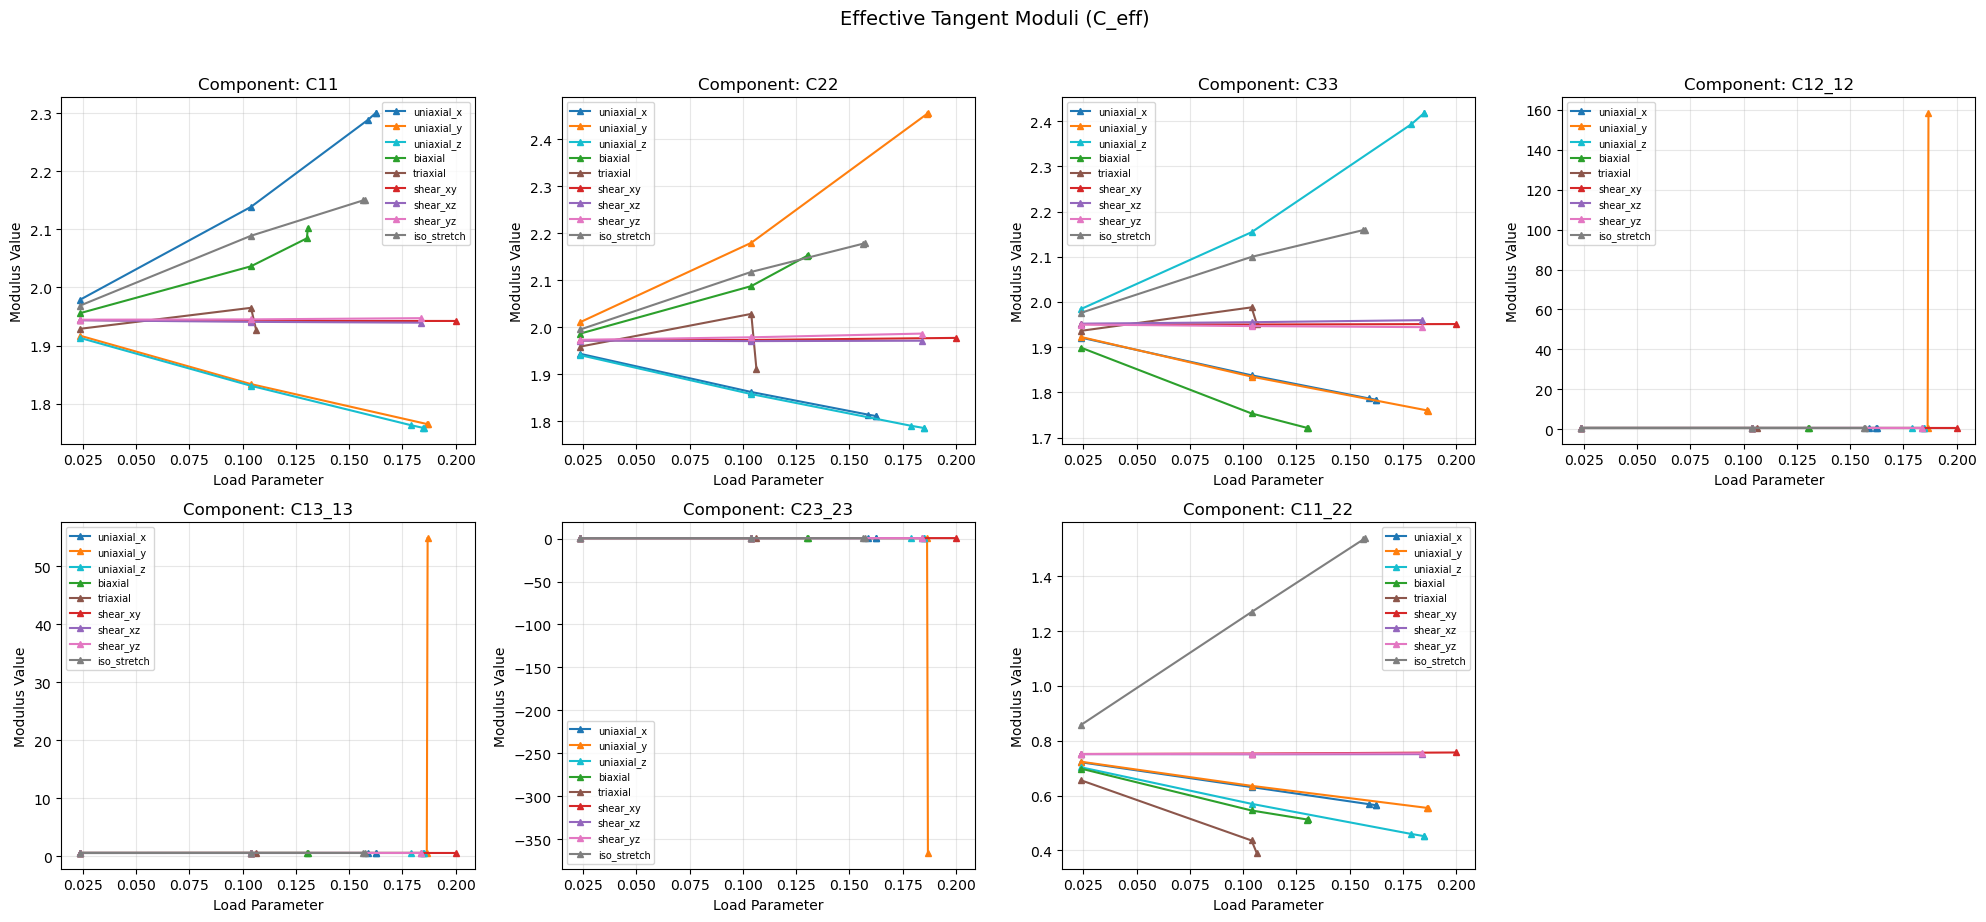

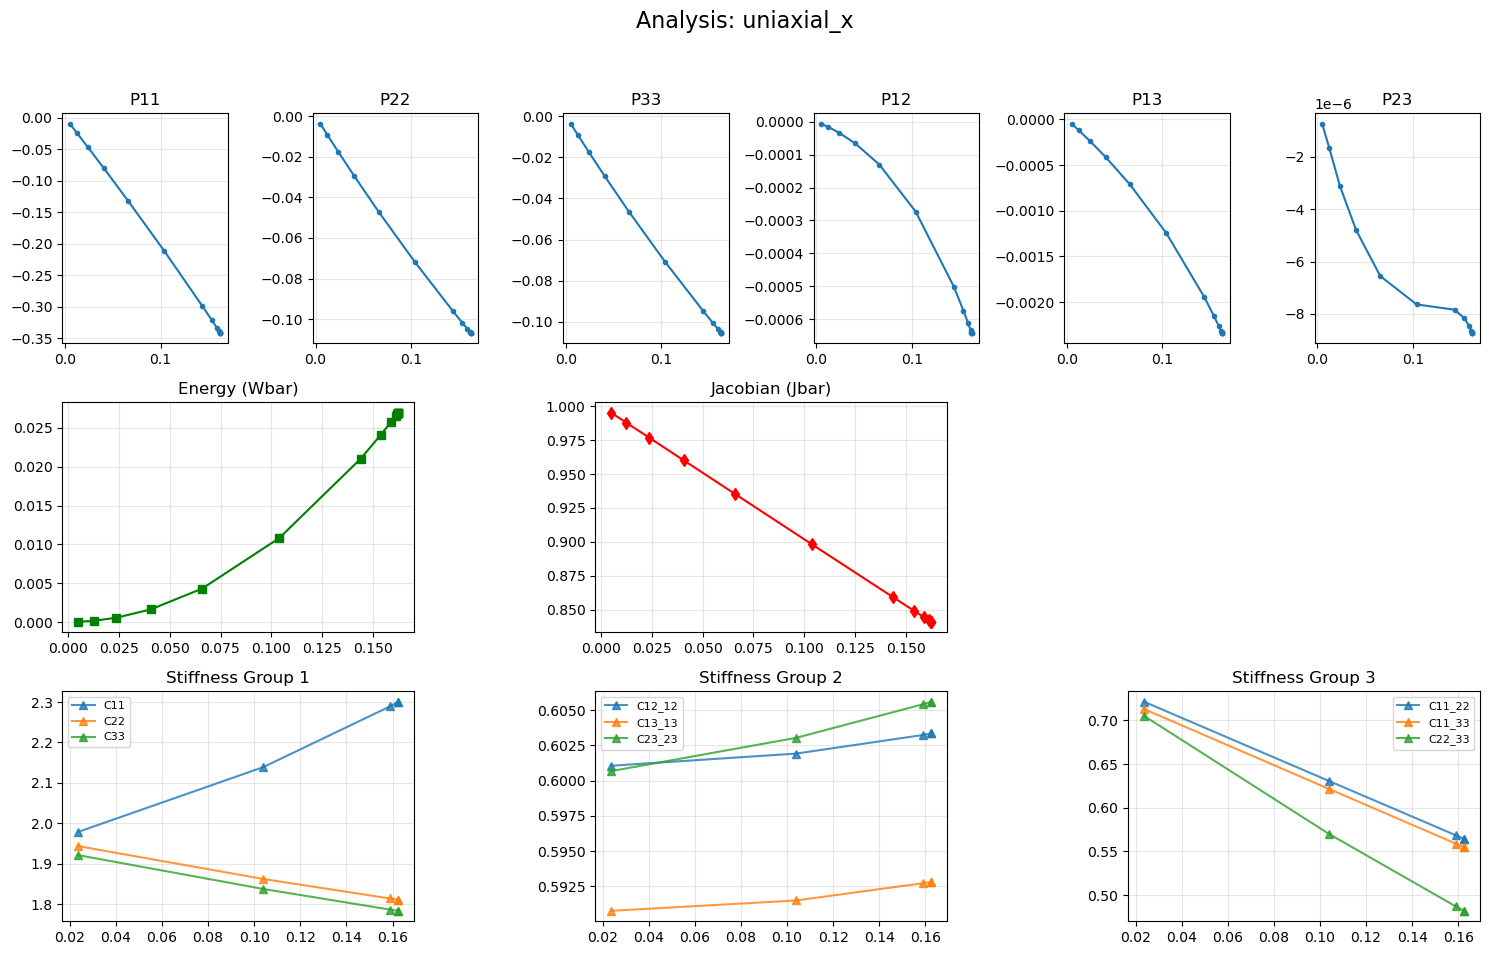

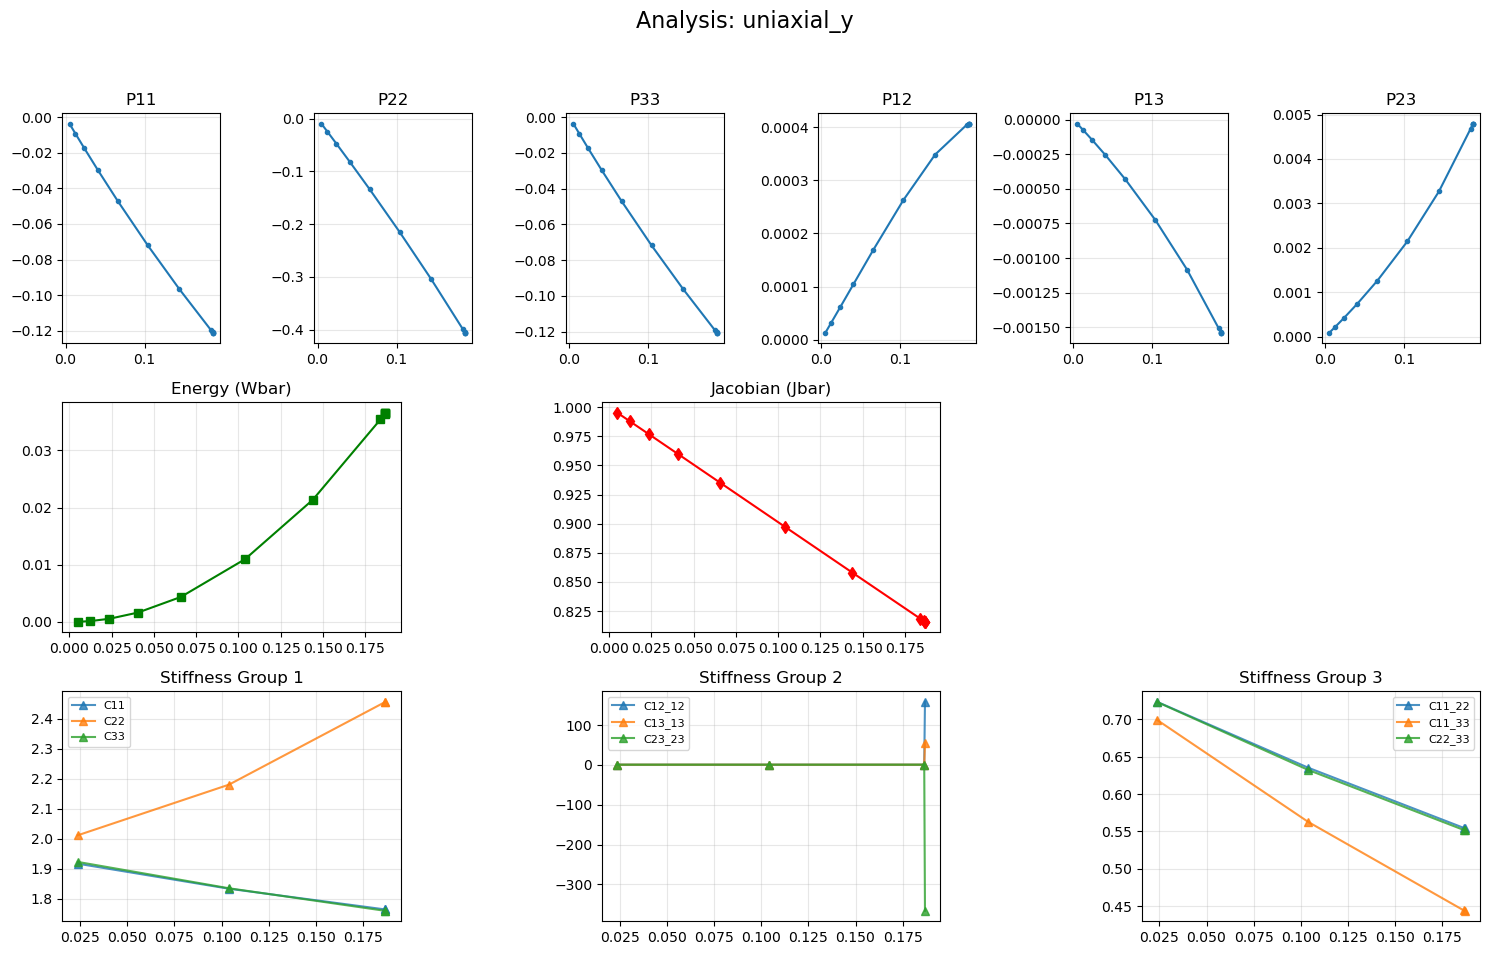

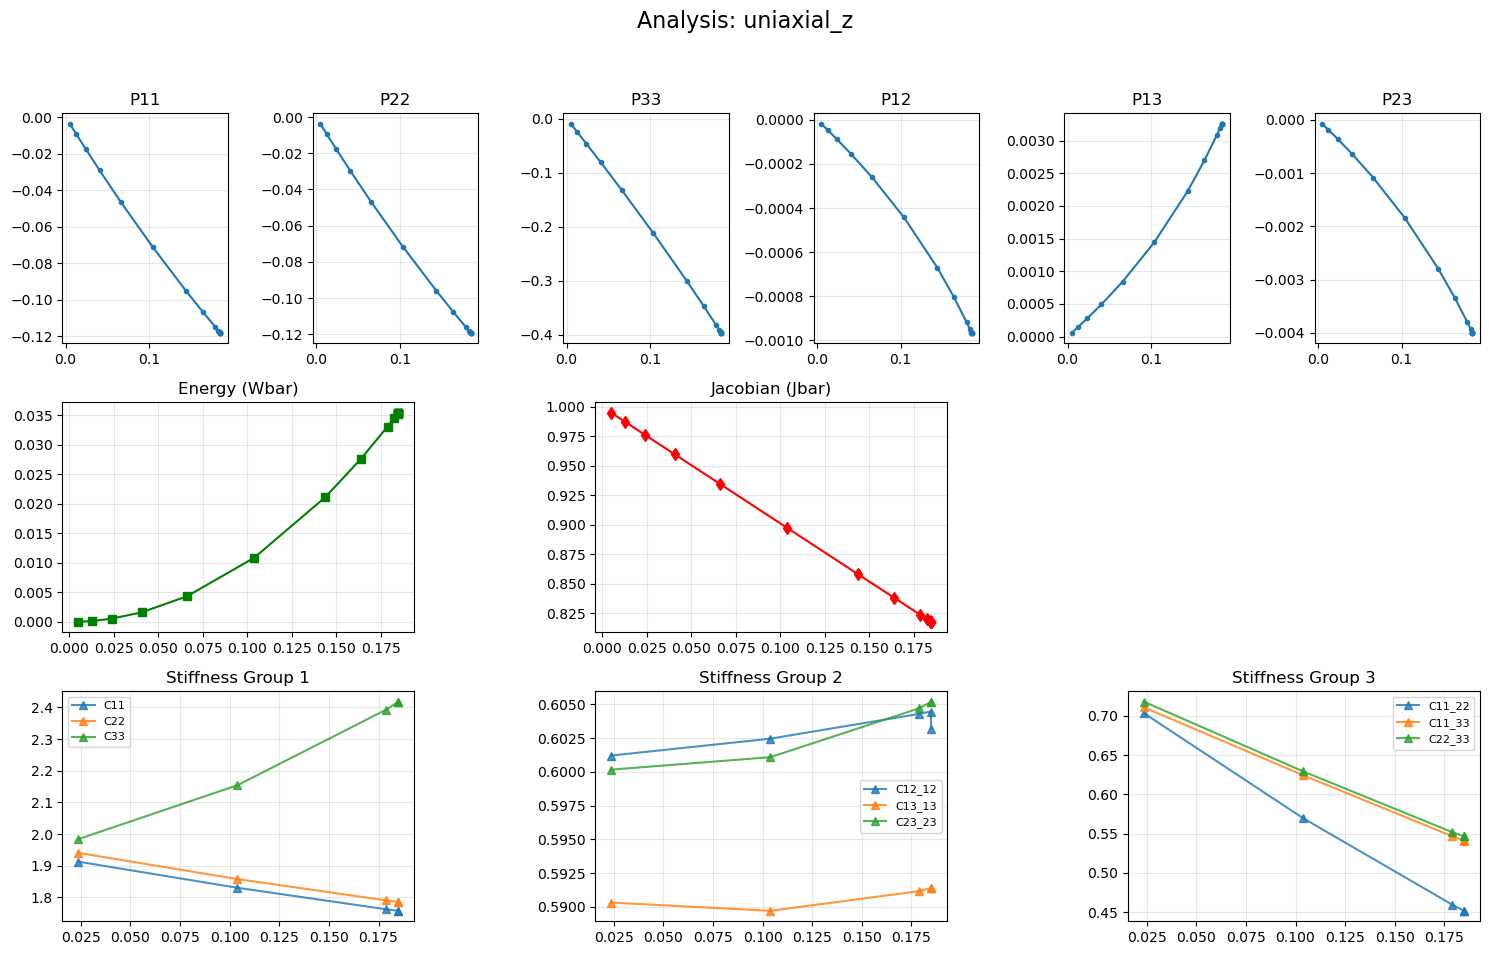

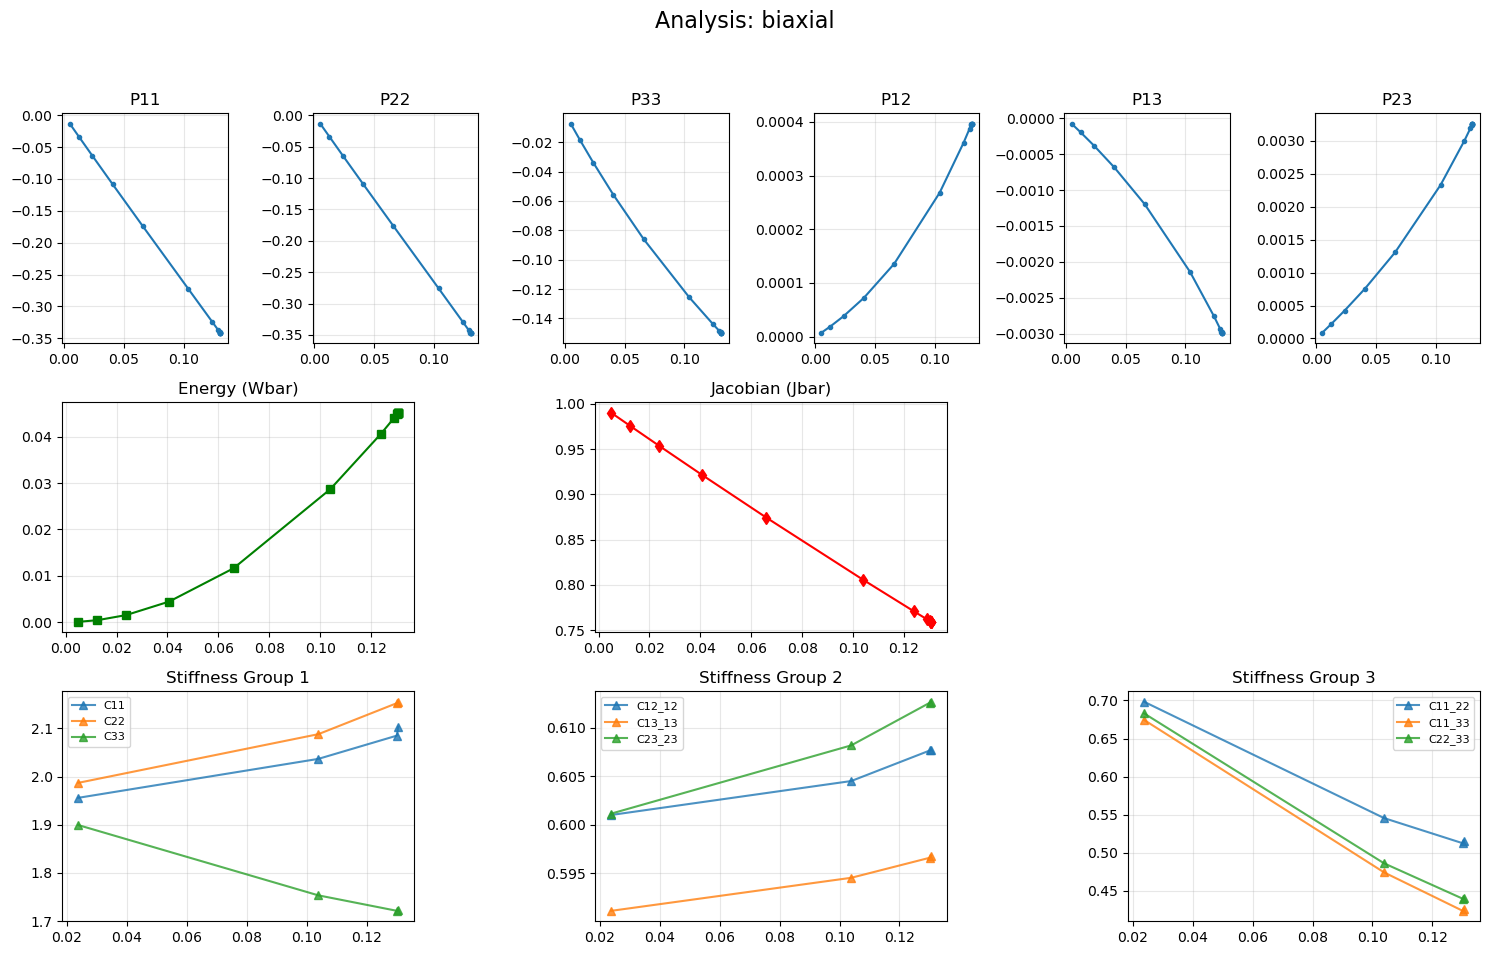

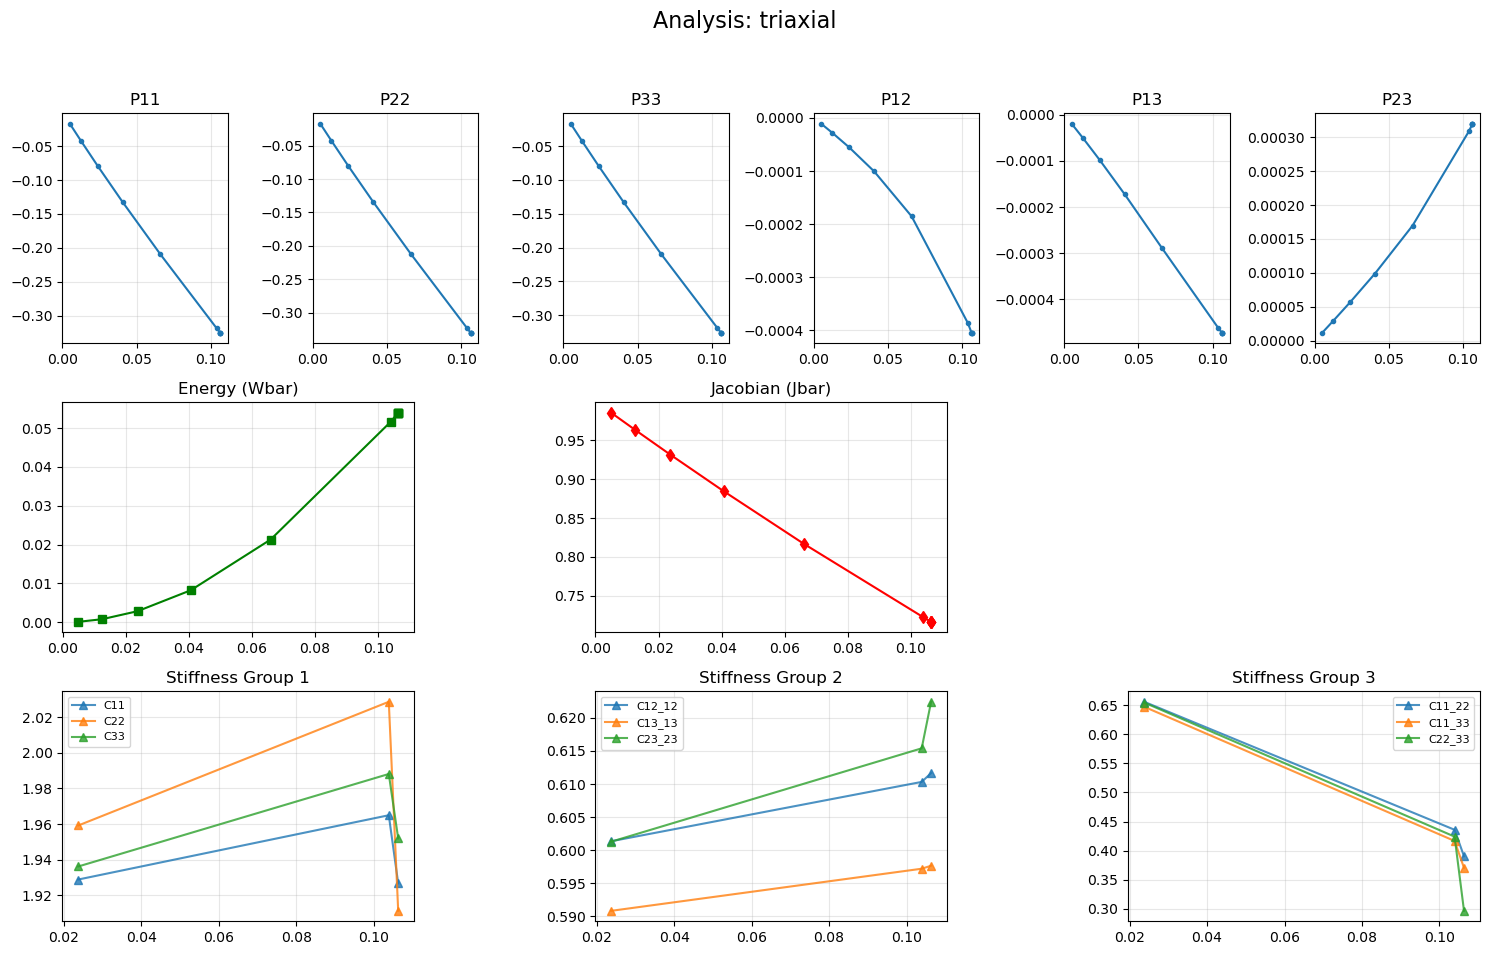

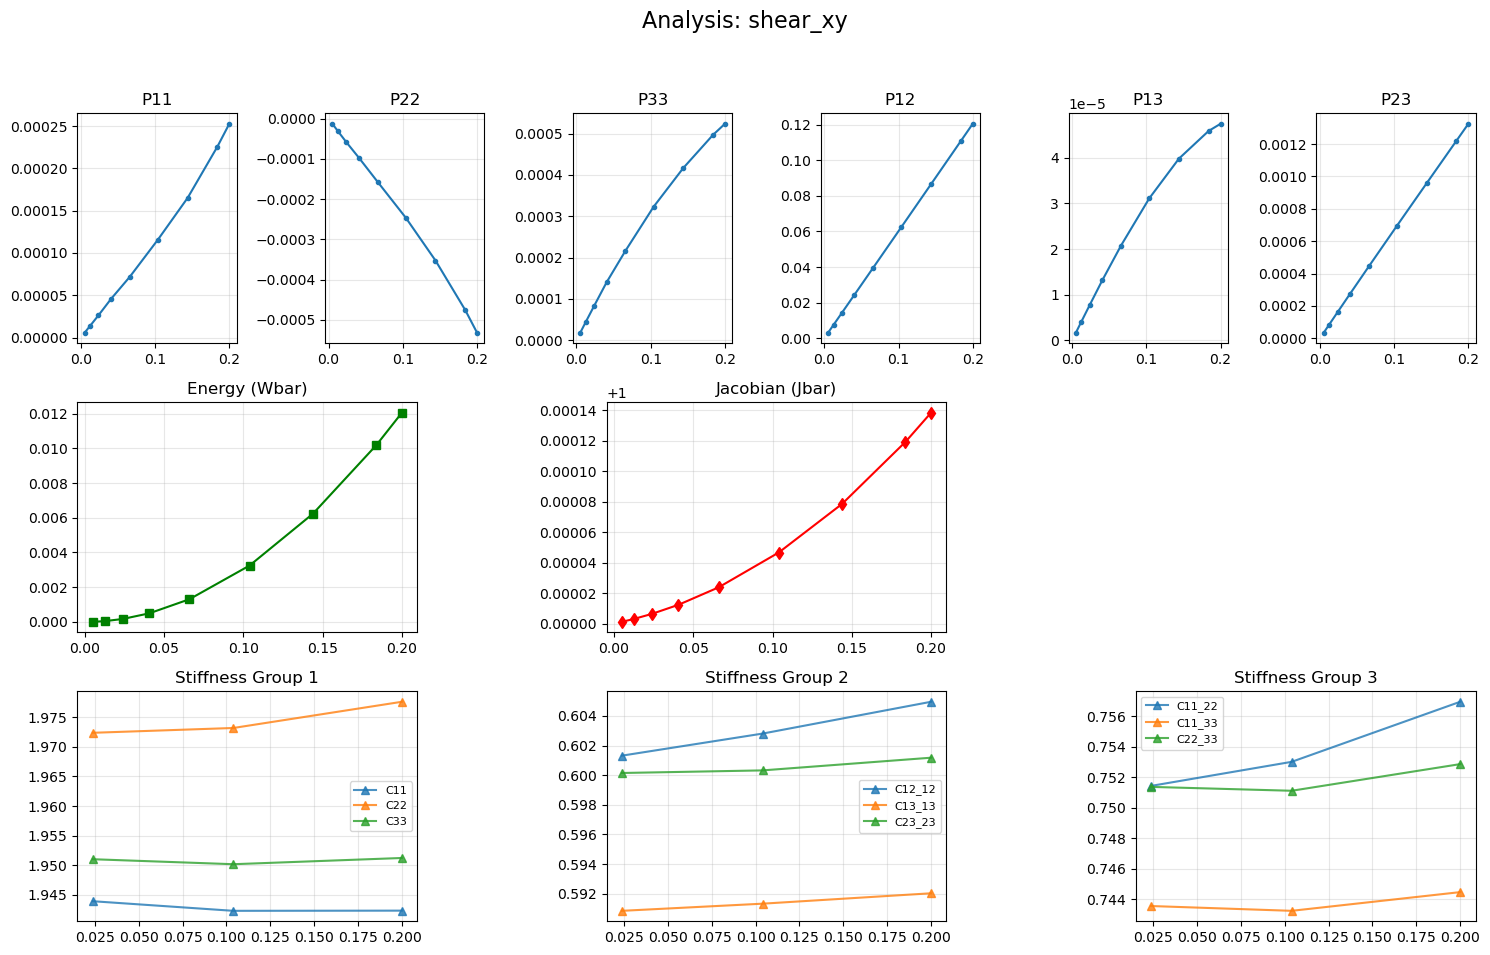

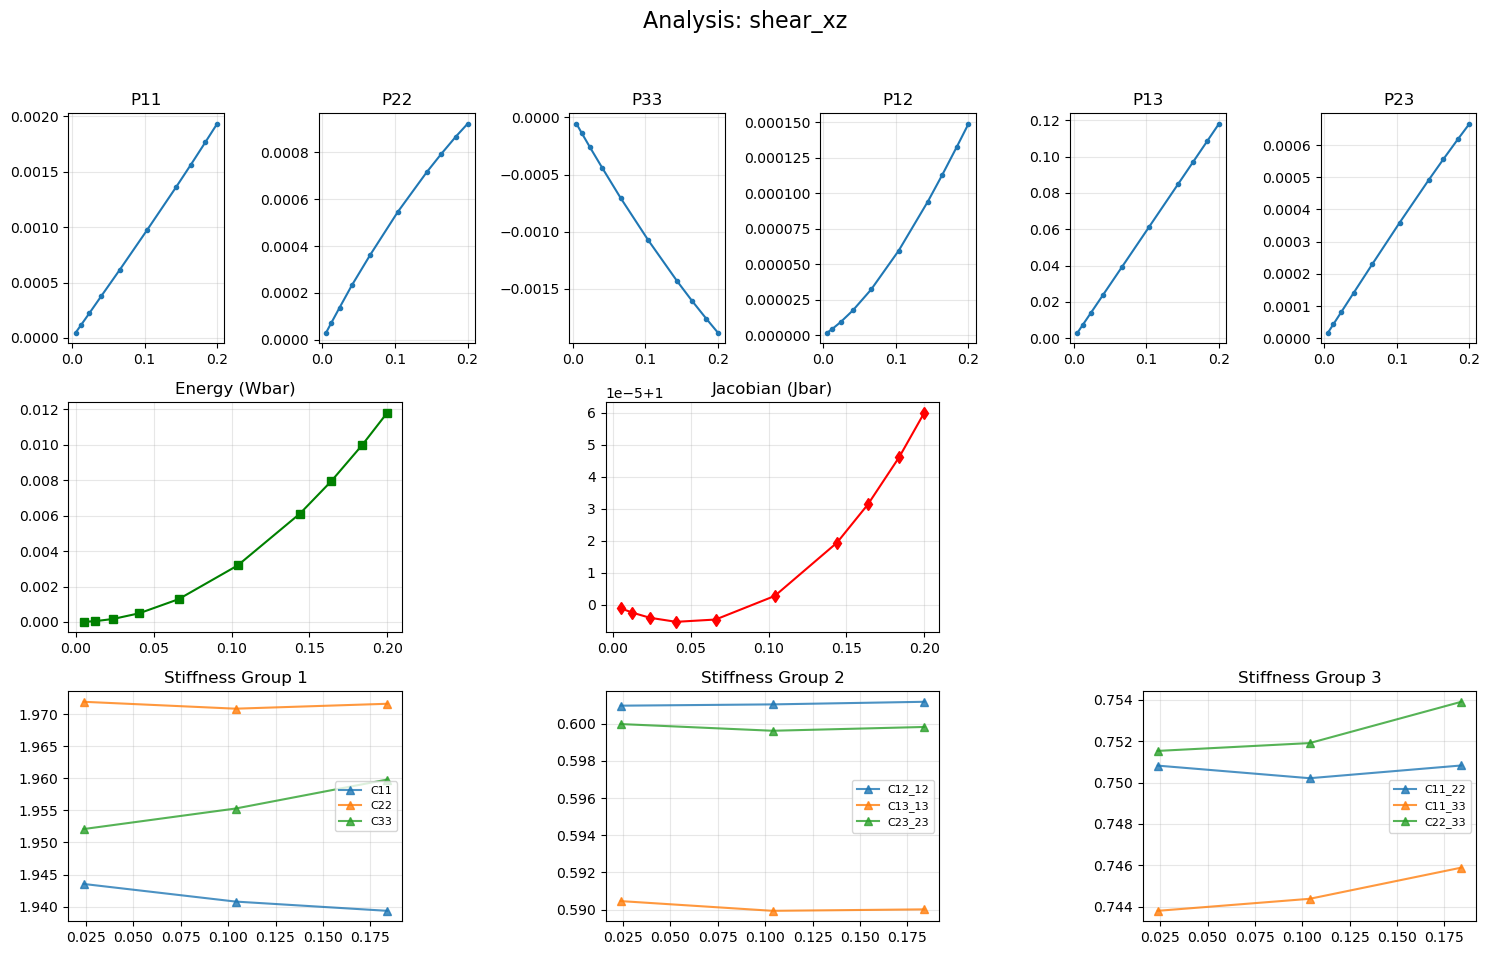

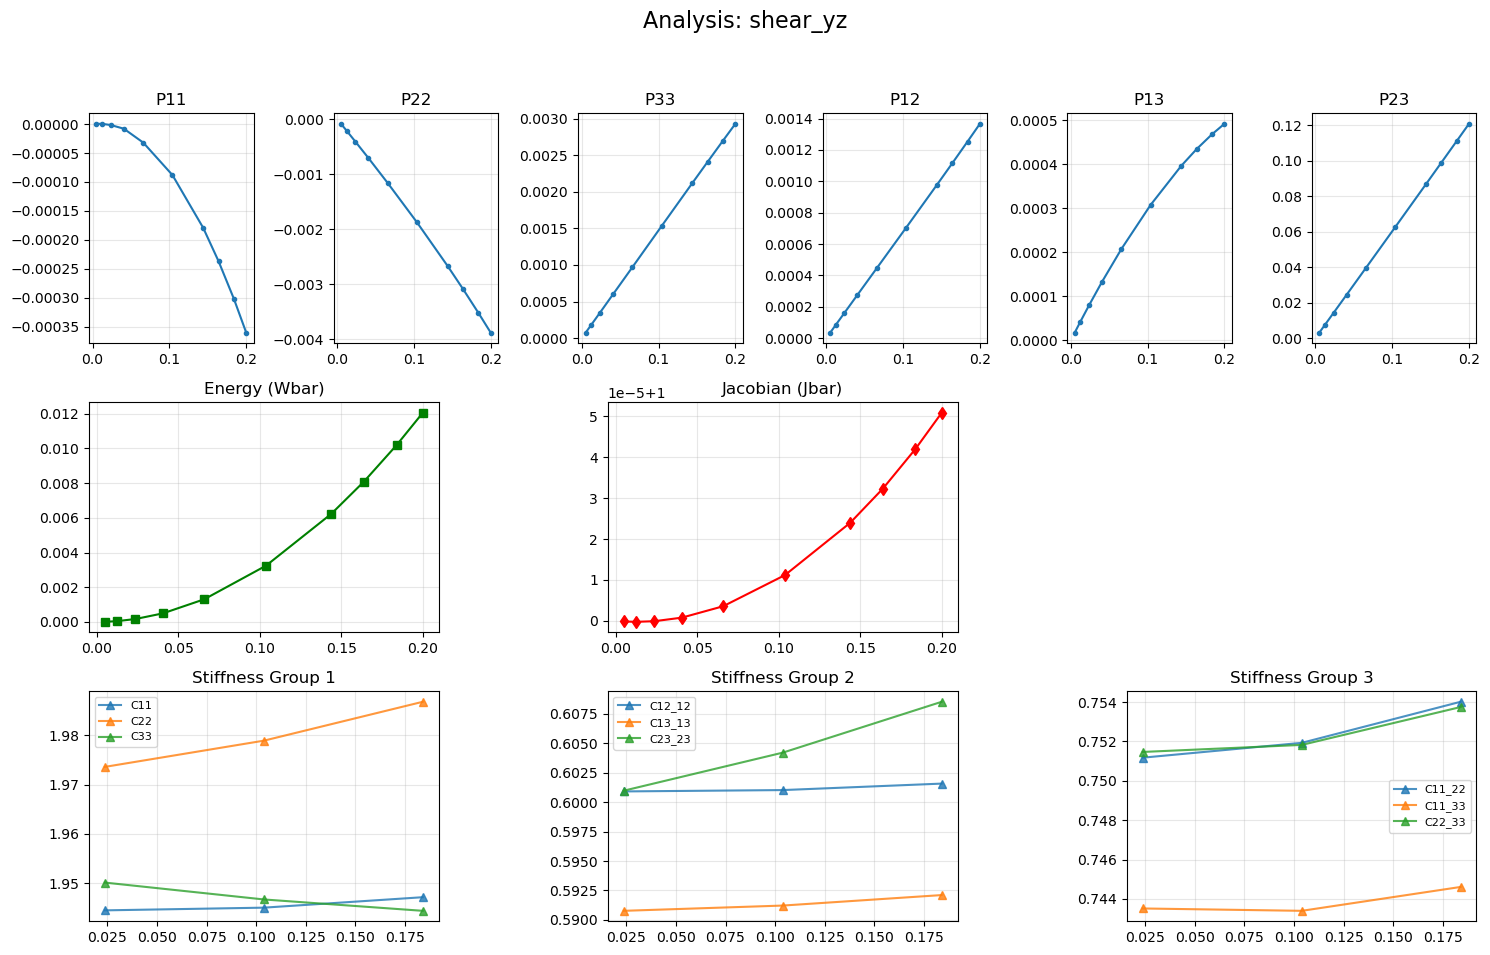

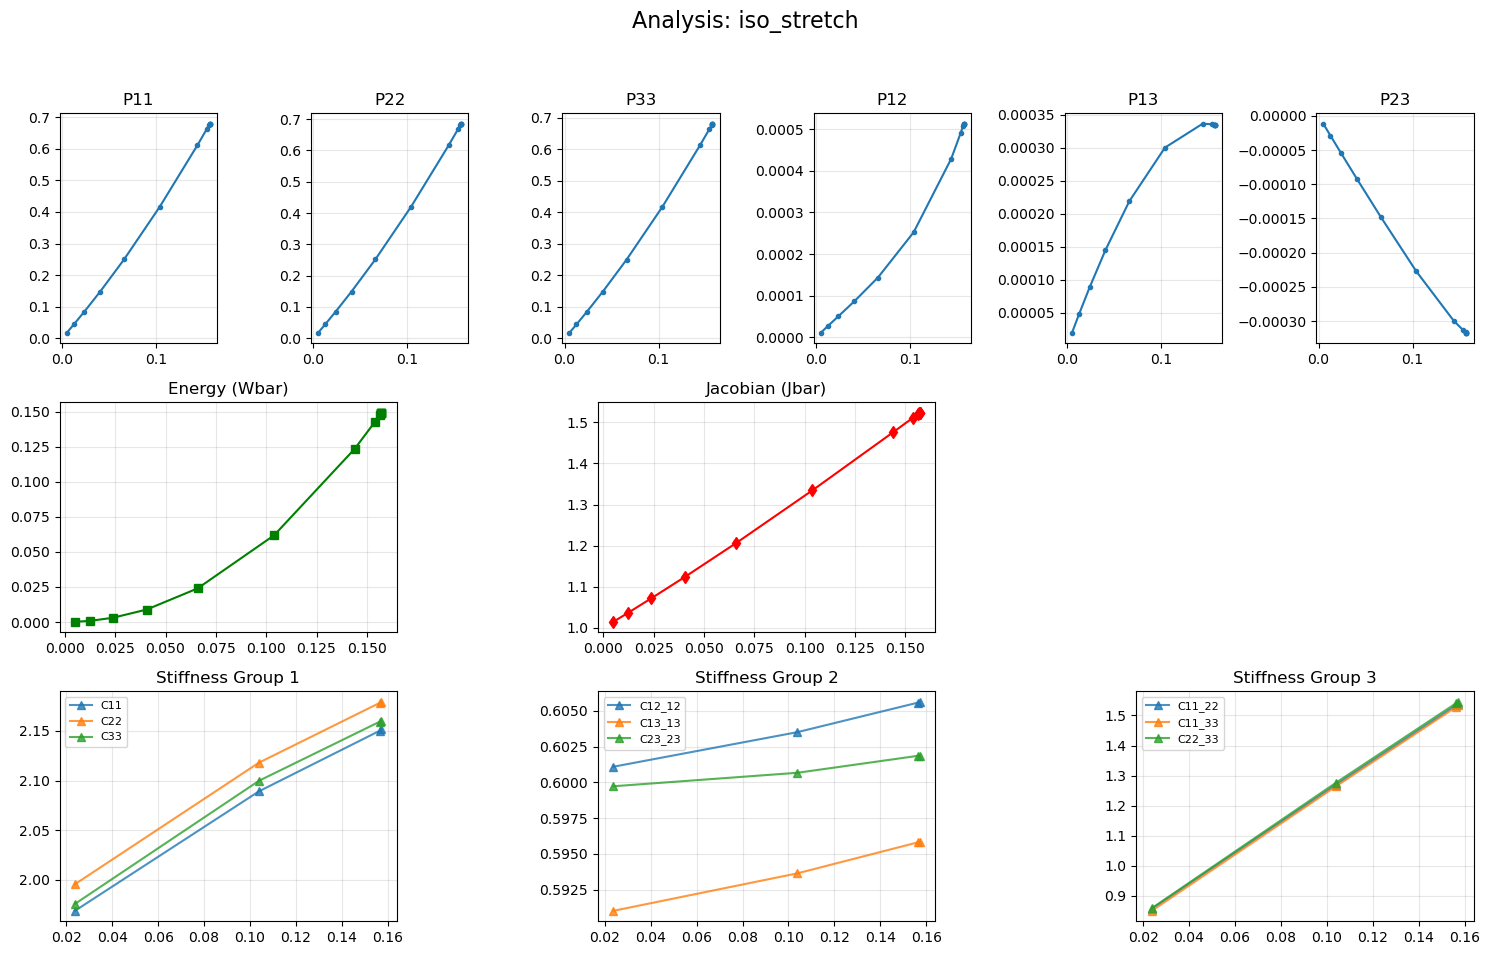

{'uniaxial_x': {'load': array([0.005     , 0.0125    , 0.02375   , 0.040625  , 0.0659375 ,
         0.10390625, 0.14390625, 0.15390625, 0.15890625, 0.16140625,
         0.16203125, 0.16234375, 0.16242188, 0.16244141, 0.16245117]),
  'P11': array([-0.00974109, -0.02442368, -0.04661894, -0.08030556, -0.13178838,
         -0.2114169 , -0.29899012, -0.32157417, -0.33298101, -0.3387141 ,
         -0.34015047, -0.34086919, -0.34104891, -0.34109384, -0.34111631]),
  'P22': array([-0.00374029, -0.00929439, -0.01750468, -0.0295418 , -0.04697689,
         -0.0717478 , -0.09606661, -0.10186374, -0.10472023, -0.10613798,
         -0.10649133, -0.10666784, -0.10671195, -0.10672298, -0.10672849]),
  'Wbar': array([2.43368614e-05, 1.52405789e-04, 5.51839917e-04, 1.62208680e-03,
         4.30389680e-03, 1.08097005e-02, 2.10039191e-02, 2.41064903e-02,
         2.57428455e-02, 2.65824603e-02, 2.67946054e-02, 2.69010147e-02,
         2.69276521e-02, 2.69343137e-02, 2.69376448e-02]),
  'Jbar': array([0.99

In [ ]:
from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    NeoHookeanIsotropic,
    ProblemSettings,
)
from homicsx.geometry import patriculate_geometry_generator
from homicsx.mesh import generate_mesh
from homicsx.homogenization import solve_nonlinear_homogenization, AdaptiveSettings
# ------------------------------------------------------------------------------
# Mesh Generation
# ------------------------------------------------------------------------------
dim = 3

geometry_input = GeometryInput(
    dim=dim,
    dispersion="mono",
    volume_fraction=0.2,
    num_particles=12,
    clearance=0.025,
    domain_size=(1, 1, 1),
    shape="sphere",
    seed=42,
)

geometry = patriculate_geometry_generator(geometry_input)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.04,
    max_size=0.06,
    physical_tags=physical_tags,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

matrix_tag = physical_tags.cell_tag_for_phase(0)
inclusion_tag = physical_tags.cell_tag_for_phase(1)

# ------------------------------------------------------------------------------
# Material assignment
# ------------------------------------------------------------------------------
E_mat = 1.0
nu_mat = 0.3
mat_matrix = NeoHookeanIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 50.0
nu_inc = 0.3
mat_particle = NeoHookeanIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

# ------------------------------------------------------------------------------
# FEM problem settings
# ------------------------------------------------------------------------------
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='finite_strain',
    two_dimensional_formulation=None,
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-6,
        "snes_atol": 1e-6,
        "snes_max_it": 10,
    }
)

summary = solve_nonlinear_homogenization(
    mesh_obj=domain,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=geometry_input.domain_size,
    matrix_phase_id=0,
    tangent_every = 3,
    tangent_delta = 1e-6,
    output_prefix = "rve",
    max_strain = 0.20,
    # loading_modes=["uniaxial_x"], #"uniaxial_y", "uniaxial_z", "shear_xy", "shear_xz", "shear_yz", "iso_stretch"]
    adaptive_settings=AdaptiveSettings(
        min_step= 1e-6,
        target_iters_min=4,
        target_iters_max=7,
    ),
    xdmf_opt=False,
    csv_opt=False,
)

plot_homogenization_summary(summary, dim=dim, save=False)
plot_each_load_case(summary, dim=dim, save=False)